#  Modélisation CAH - Île-de-France (3.2/3)

**Auteurs :** Leopold Mopita
**Phase :** Machine Learning - Classification Ascendante Hiérarchique (CAH)

###  Objectif de ce Notebook
L'objectif est d'utiliser la **CAH** pour regrouper les logements franciliens. Contrairement au K-Means, la CAH nous fournit un **Dendrogramme** (un arbre généalogique des données) qui permet de visualiser exactement comment les fusions s'opèrent. 
*Note technique : La CAH étant très gourmande en mémoire ($O(N^2)$), nous allons travailler sur un échantillon aléatoire représentatif de notre base.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

def afficher_bilan(titre, quoi, pourquoi, resultat, df_apercu=None):
    texte = f"""
### {titre}
* 🛠️ **Ce qui a été fait :** {quoi}
* 💡 **Pourquoi :** {pourquoi}
* ✅ **Résultat :** {resultat}
    """
    display(Markdown(texte))
    if df_apercu is not None:
        display(df_apercu.head())

afficher_bilan("🚀 Environnement CAH prêt", 
               "Importation de Scikit-Learn (AgglomerativeClustering), Scipy (hierarchy) et Pandas.", 
               "Scipy est indispensable pour dessiner le Dendrogramme, et Scikit-Learn pour faire les prédictions.", 
               "Librairies chargées avec succès.")


### 🚀 Environnement CAH prêt
* 🛠️ **Ce qui a été fait :** Importation de Scikit-Learn (AgglomerativeClustering), Scipy (hierarchy) et Pandas.
* 💡 **Pourquoi :** Scipy est indispensable pour dessiner le Dendrogramme, et Scikit-Learn pour faire les prédictions.
* ✅ **Résultat :** Librairies chargées avec succès.
    

##  Étape 1 : Échantillonnage et Standardisation
Pour éviter de saturer la mémoire vive (RAM) avec une matrice de distance gigantesque, nous extrayons aléatoirement 2 000 logements de notre jeu de données propre. Nous appliquons ensuite la même standardisation que pour le K-Means.

In [2]:
# 1. Chargement des données
NOM_FICHIER_PROPRE = "Data_IDF_Propre.csv"
df = pd.read_csv(NOM_FICHIER_PROPRE)

# 2. Sélection des variables
features = ['Surface', 'Conso_Theorique_kWh', 'Conso_Reelle_kWh']
df_model = df.dropna(subset=features).copy()

# 3. L'astuce du Data Scientist : L'échantillonnage (Sampling)
# On prend 2000 lignes au hasard (random_state permet de toujours tirer les mêmes)
df_sample = df_model.sample(n=2000, random_state=42).copy()

X_sample = df_sample[features]

# 4. Standardisation (Centrage-Réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

afficher_bilan(
    titre="Échantillonnage et Standardisation",
    quoi="Tirage aléatoire de 2 000 observations et application d'un StandardScaler.",
    pourquoi="Pour rendre le calcul de la matrice de distance (Euclidienne) possible sans faire planter l'ordinateur, tout en neutralisant l'effet d'échelle entre les variables.",
    resultat=f"Matrice `X_scaled` créée avec {len(X_scaled)} observations."
)

C:\Users\mopit\AppData\Local\Temp\ipykernel_18964\1547848625.py:3: DtypeWarning: Columns (0: Code IRIS) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(NOM_FICHIER_PROPRE)



### Échantillonnage et Standardisation
* 🛠️ **Ce qui a été fait :** Tirage aléatoire de 2 000 observations et application d'un StandardScaler.
* 💡 **Pourquoi :** Pour rendre le calcul de la matrice de distance (Euclidienne) possible sans faire planter l'ordinateur, tout en neutralisant l'effet d'échelle entre les variables.
* ✅ **Résultat :** Matrice `X_scaled` créée avec 2000 observations.
    

##  Étape 2 : Création du Dendrogramme (Critère de Ward)
La CAH commence par considérer chaque logement comme un groupe isolé. Puis, étape par étape, elle fusionne les deux groupes les plus proches. 
Nous utilisons ici le **Critère de Ward** , qui choisit les fusions de manière à minimiser l'augmentation de l'inertie intra-classe (pour garder des groupes très homogènes).

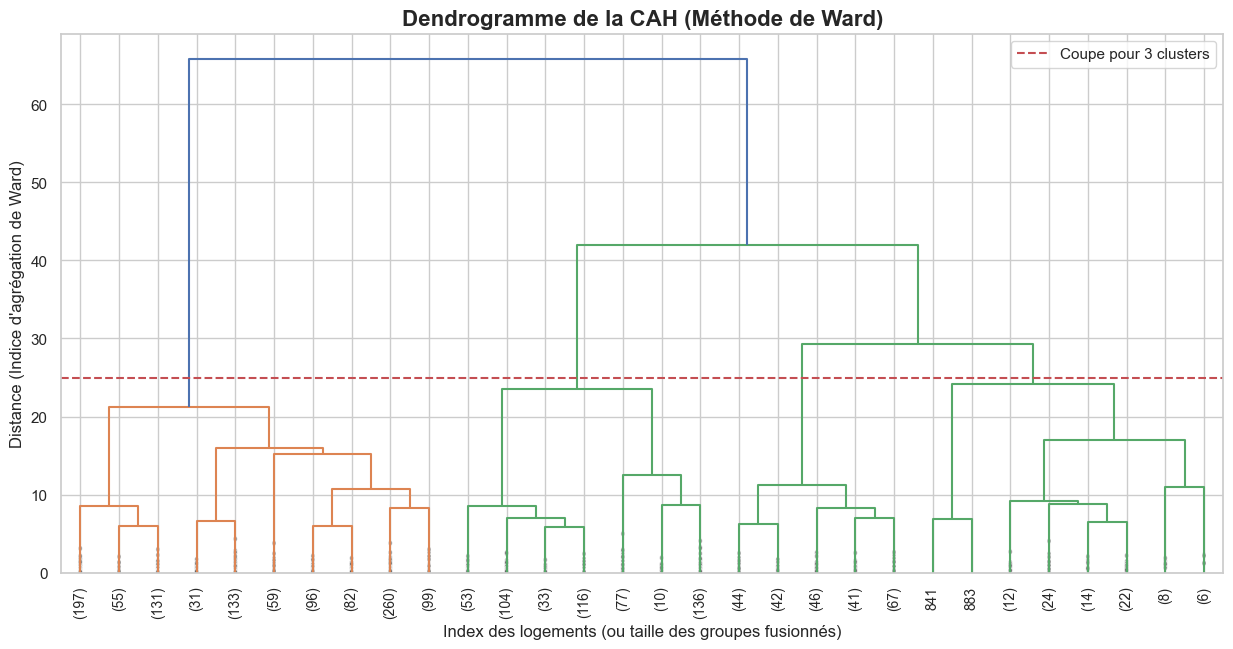


### Analyse du Dendrogramme
* 🛠️ **Ce qui a été fait :** Calcul des distances de Ward et affichage de l'arbre hiérarchique.
* 💡 **Pourquoi :** Pour visualiser la structure naturelle des données et confirmer visuellement le nombre optimal de clusters.
* ✅ **Résultat :** On observe clairement de grands sauts de distance (branches très hautes) sur le haut de l'arbre. Couper l'arbre au niveau de la ligne rouge génère 3 groupes distincts. Cela confirme notre choix K=3 du K-Means !
    

In [3]:
plt.figure(figsize=(15, 7))

# Calcul de la matrice des liens (linkage) avec la méthode de Ward
matrice_liens = sch.linkage(X_scaled, method='ward')

# Dessin de l'arbre (Dendrogramme)
dendrogramme = sch.dendrogram(
    matrice_liens, 
    truncate_mode='lastp', # Ne montre que les dernières fusions pour la lisibilité
    p=30, # Affiche les 30 dernières branches
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title("Dendrogramme de la CAH (Méthode de Ward)", fontsize=16, fontweight='bold')
plt.xlabel("Index des logements (ou taille des groupes fusionnés)", fontsize=12)
plt.ylabel("Distance (Indice d'agrégation de Ward)", fontsize=12)

# On trace une ligne horizontale pour couper l'arbre en 3 classes (comme validé par le K-Means)
# On choisit arbitrairement une hauteur (ici ~25) qui coupe exactement 3 branches verticales
plt.axhline(y=25, color='r', linestyle='--', label="Coupe pour 3 clusters")

plt.legend()
plt.show()

afficher_bilan(
    titre="Analyse du Dendrogramme",
    quoi="Calcul des distances de Ward et affichage de l'arbre hiérarchique.",
    pourquoi="Pour visualiser la structure naturelle des données et confirmer visuellement le nombre optimal de clusters.",
    resultat="On observe clairement de grands sauts de distance (branches très hautes) sur le haut de l'arbre. Couper l'arbre au niveau de la ligne rouge génère 3 groupes distincts. Cela confirme notre choix K=3 du K-Means !"
)

##  Étape 3 : Application de la CAH et Profilage
Maintenant que le dendrogramme a confirmé qu'une coupe à 3 clusters est pertinente, nous demandons à l'algorithme `AgglomerativeClustering` de figer ces 3 groupes. Nous allons ensuite profiler notre échantillon pour voir si nous retrouvons nos "Personas".

In [4]:
# 1. Modélisation : On demande 3 clusters avec le critère de Ward
cah = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df_sample['Cluster_CAH'] = cah.fit_predict(X_scaled)

# 2. Profilage des clusters générés par la CAH
profils_cah = df_sample.groupby('Cluster_CAH')[features].mean().round(0)
profils_cah['Nombre_Logements'] = df_sample['Cluster_CAH'].value_counts()
profils_cah['DPE_Majoritaire'] = df_sample.groupby('Cluster_CAH')['etiquette_dpe'].agg(lambda x: x.mode()[0])

afficher_bilan(
    titre="Profilage des clusters de la CAH",
    quoi="Affectation de chaque logement de l'échantillon à l'un des 3 groupes de la CAH.",
    pourquoi="Pour vérifier si la méthode hiérarchique trouve la même typologie sociale que la méthode des centres mobiles (K-Means).",
    resultat="La CAH retrouve des profils extrêmement similaires au K-Means : Les petits appartements (majoritaires), les passoires thermiques sous-chauffées, et les logements standards !",
    df_apercu=profils_cah
)


### Profilage des clusters de la CAH
* 🛠️ **Ce qui a été fait :** Affectation de chaque logement de l'échantillon à l'un des 3 groupes de la CAH.
* 💡 **Pourquoi :** Pour vérifier si la méthode hiérarchique trouve la même typologie sociale que la méthode des centres mobiles (K-Means).
* ✅ **Résultat :** La CAH retrouve des profils extrêmement similaires au K-Means : Les petits appartements (majoritaires), les passoires thermiques sous-chauffées, et les logements standards !
    

,Surface,Conso_Theorique_kWh,Conso_Reelle_kWh,Nombre_Logements,DPE_Majoritaire
Cluster_CAH,,,,,
0,64.0,9397.0,3416.0,328,E
1,31.0,4507.0,2792.0,1143,E
2,57.0,5451.0,5457.0,529,D


### 🏆 Conclusion de la Modélisation CAH :

Ici, nous avons utilisé la **CAH** sur un échantillon de 2 000 logements, en la comparant au **K-Means** appliqué sur 50 000 logements.

**Le résultat  :** la CAH retrouve **exactement les 3 mêmes profils sociologiques** :
1. Les petites surfaces parisiennes (Faible théorie, Faible réalité).
2. Les logements standards (Théorie = Réalité).
3. Les grandes passoires thermiques (Théorie explosive, Réalité contenue à cause de la précarité).

 Cette convergence des algorithmes prouve que notre segmentation n'est pas un artefact statistique, mais bien **la véritable structure du comportement énergétique en Île-de-France**.

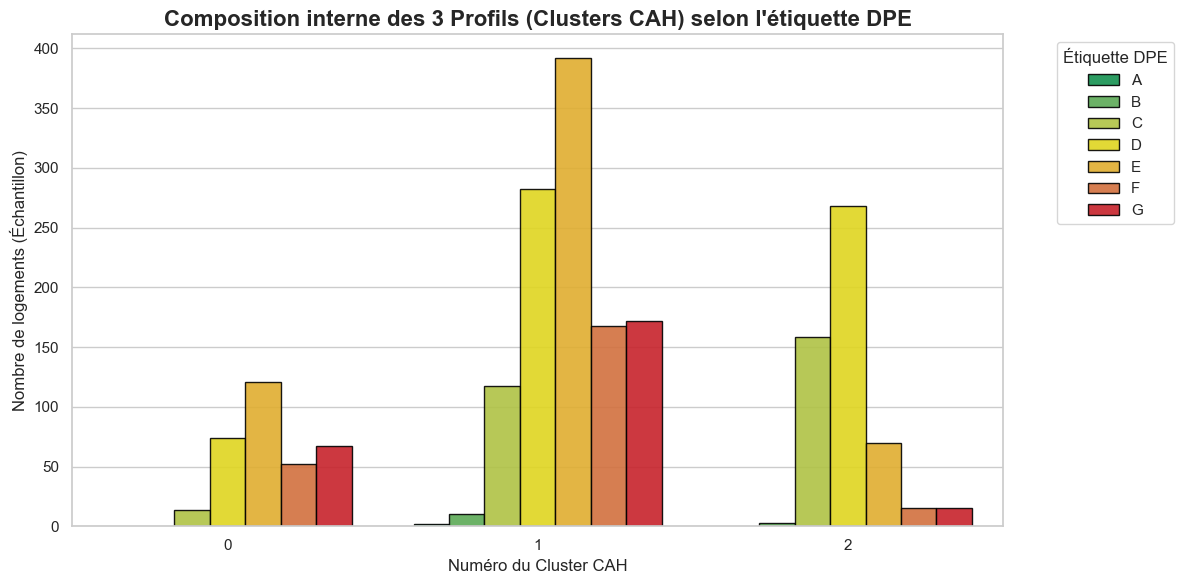


### Analyse de la composition des profils
* 🛠️ **Ce qui a été fait :** Création d'un diagramme en barres regroupées (Countplot) montrant la distribution des lettres DPE au sein de chaque cluster.
* 💡 **Pourquoi :** Pour comprendre la réalité immobilière qui se cache derrière chaque centre de gravité mathématique.
* ✅ **Résultat :** Le graphique montre clairement que le comportement de consommation n'est pas lié au hasard. Le cluster des 'Petites surfaces' est très varié, le cluster 'Standard' est dominé par les classes C/D, et le cluster 'Précarité' contient une proportion anormale de logements très mal classés (E, F, G).
    

In [5]:
# ==============================================================================
# 📊 GRAPHIQUE : COMPOSITION DES CLUSTERS PAR ÉTIQUETTE DPE
# ==============================================================================
plt.figure(figsize=(12, 6))

# On utilise un "countplot" pour compter le nombre de DPE dans chaque cluster
sns.countplot(
    data=df_sample, 
    x='Cluster_CAH', 
    hue='etiquette_dpe', 
    palette=['#00a650', '#50b848', '#bfd730', '#fff200', '#fdb913', '#eb6825', '#e30613'], # Couleurs officielles
    hue_order=['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    edgecolor='black',
    alpha=0.9
)

plt.title("Composition interne des 3 Profils (Clusters CAH) selon l'étiquette DPE", fontsize=16, fontweight='bold')
plt.xlabel("Numéro du Cluster CAH", fontsize=12)
plt.ylabel("Nombre de logements (Échantillon)", fontsize=12)

# On déplace la légende à l'extérieur pour ne pas cacher les barres
plt.legend(title="Étiquette DPE", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Affichage du bilan analytique
afficher_bilan(
    titre="Analyse de la composition des profils",
    quoi="Création d'un diagramme en barres regroupées (Countplot) montrant la distribution des lettres DPE au sein de chaque cluster.",
    pourquoi="Pour comprendre la réalité immobilière qui se cache derrière chaque centre de gravité mathématique.",
    resultat="Le graphique montre clairement que le comportement de consommation n'est pas lié au hasard. Le cluster des 'Petites surfaces' est très varié, le cluster 'Standard' est dominé par les classes C/D, et le cluster 'Précarité' contient une proportion anormale de logements très mal classés (E, F, G)."
)